# R4 | Project | Superived Learning 

# Thera Bank | Campaign for selling personal loans

In [1]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

In [2]:
# Import data

thera_df = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")

In [3]:
thera_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:
thera_df=thera_df.set_index('ID')

In [5]:
thera_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


In [6]:
thera_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 1 to 5000
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(12)
memory usage: 546.9 KB


#  Experience has negative values. WHich is logically not possible
# Hence replacing Negative values with Median of Experience Column 

In [7]:
thera_df[thera_df["Experience"]<0]["Experience"].value_counts()

thera_df[thera_df["Experience"]==0]["Age"].value_counts()

-1    33
-2    15
-3     4
Name: Experience, dtype: int64

26    28
25    17
24    11
27     8
30     1
29     1
Name: Age, dtype: int64

In [8]:
thera_df["Experience"].median()

20.0

In [9]:

thera_df.loc[thera_df["Experience"]<0, 'Experience'] = thera_df["Experience"].median()

In [10]:
thera_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.327600,11.253035,0.0,11.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


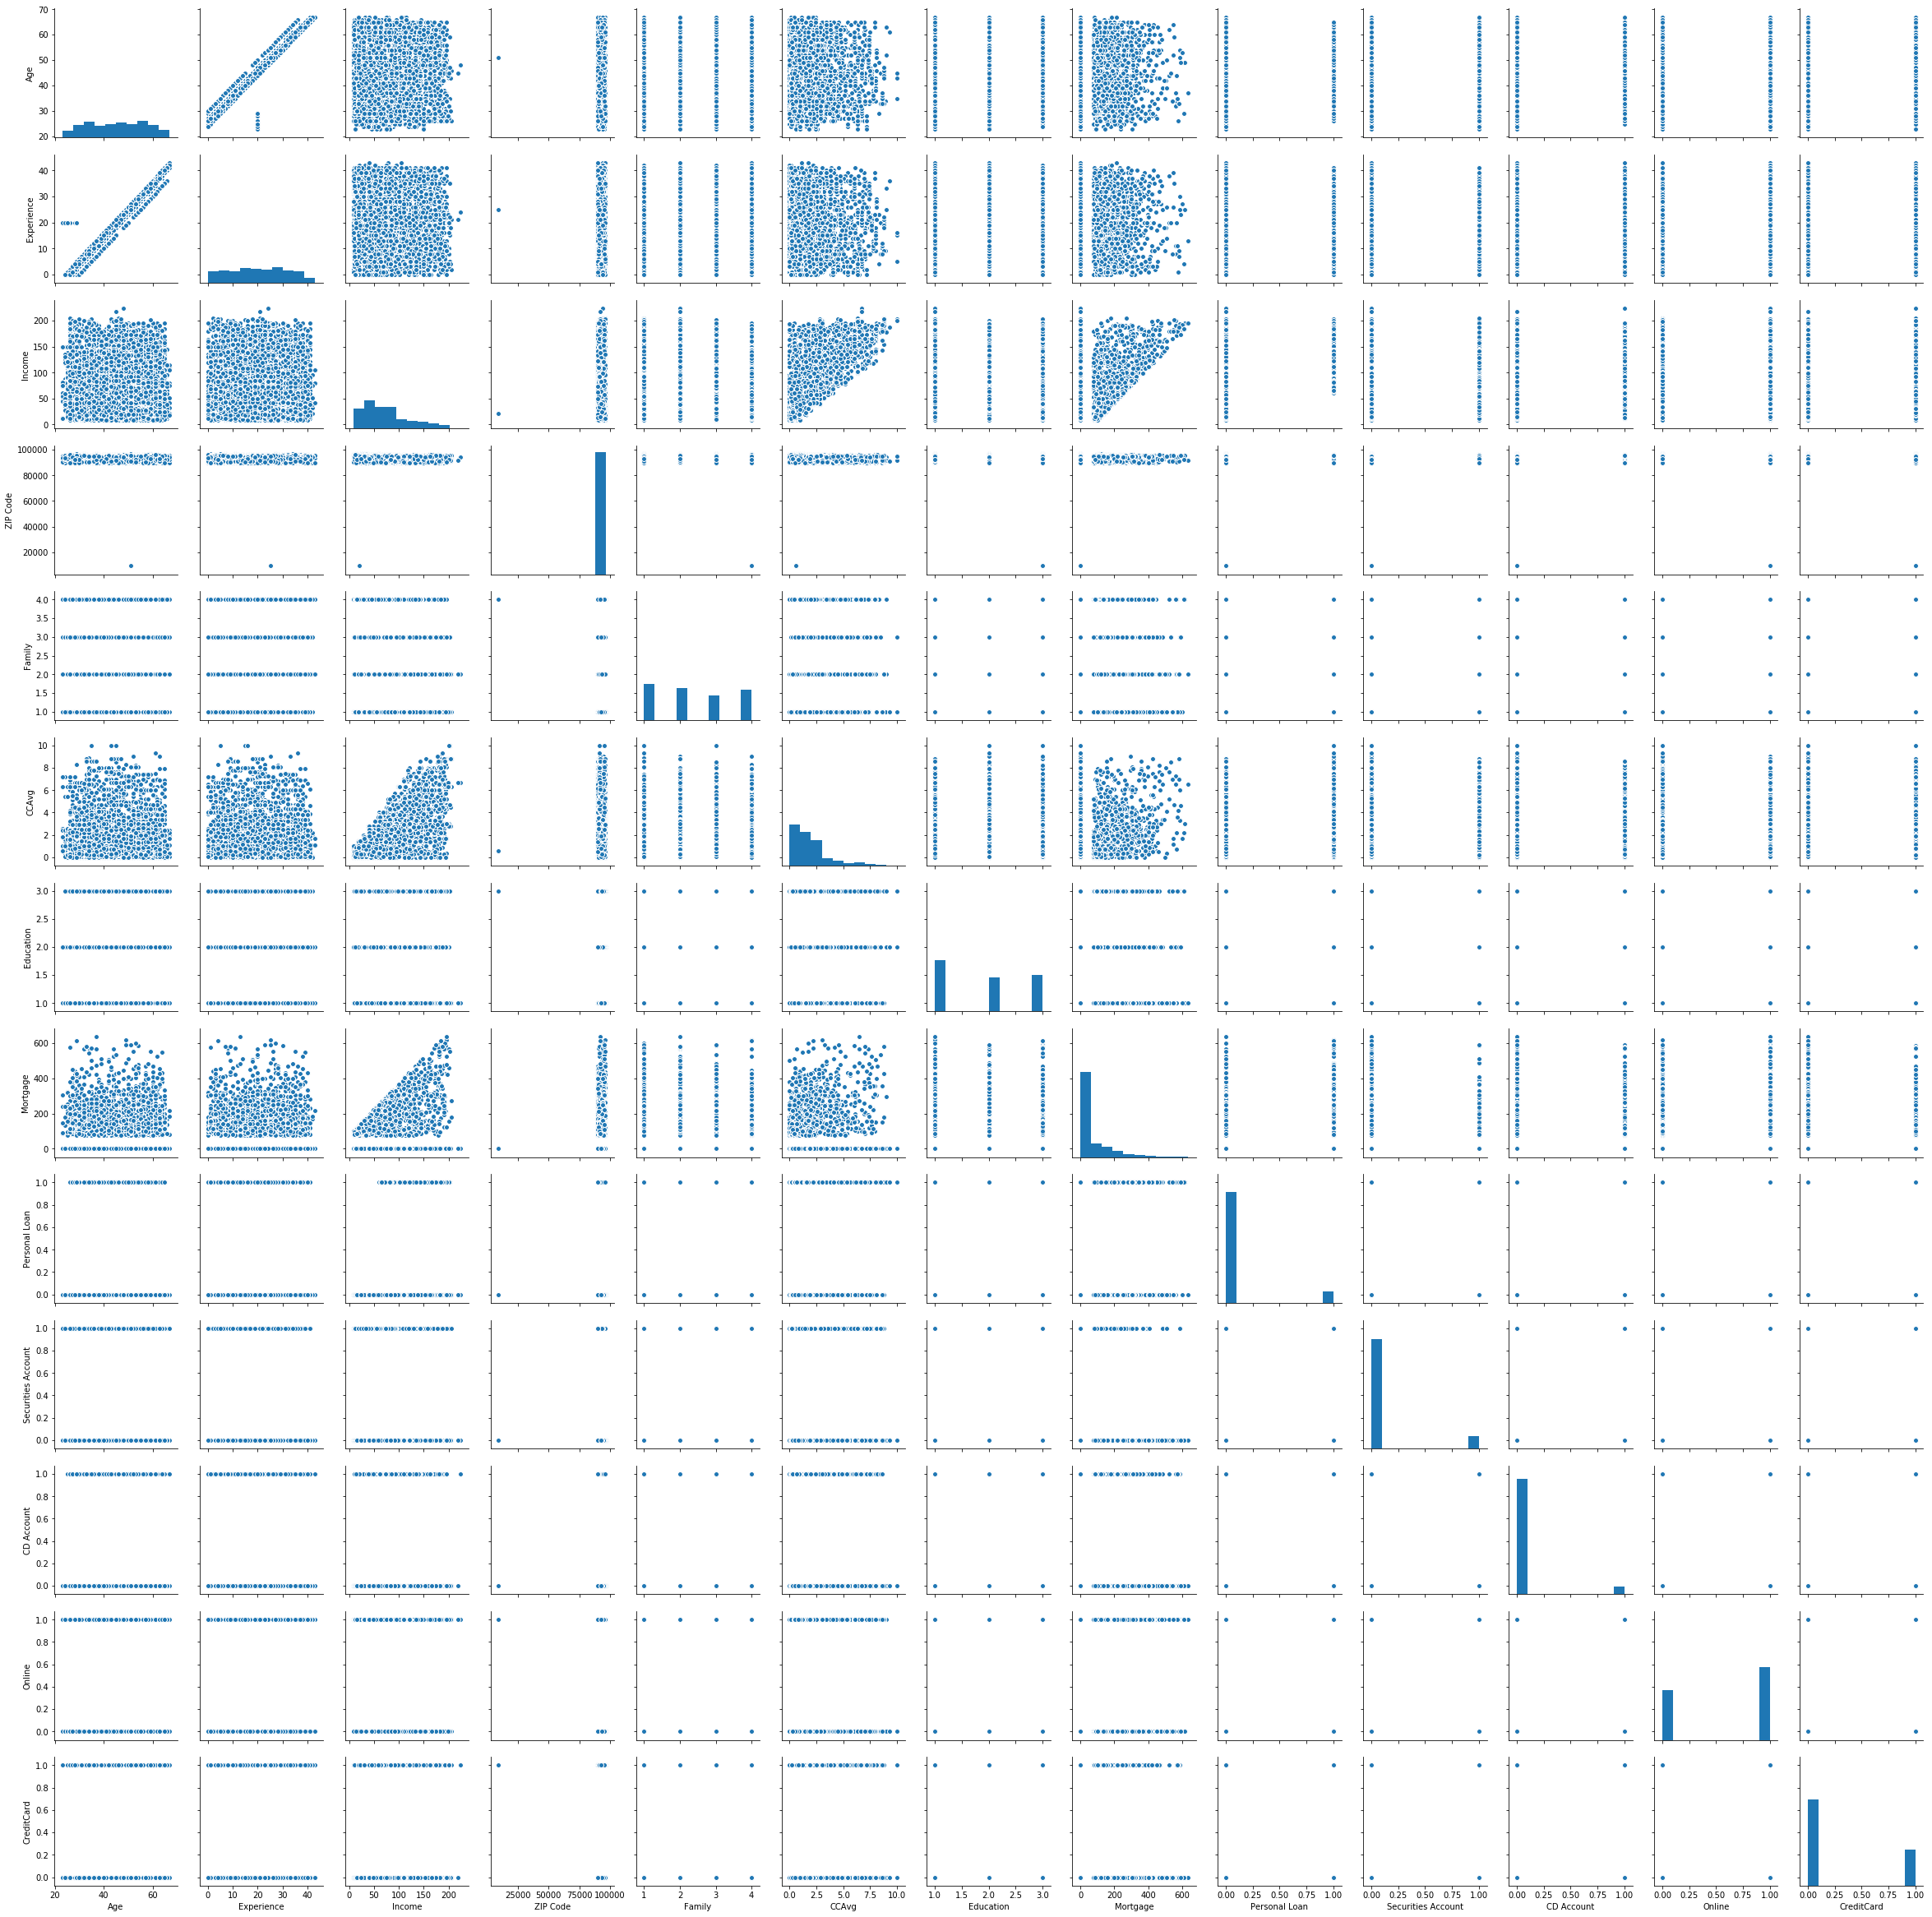

In [11]:
sns.pairplot(thera_df)

<Figure size 1080x1080 with 0 Axes>

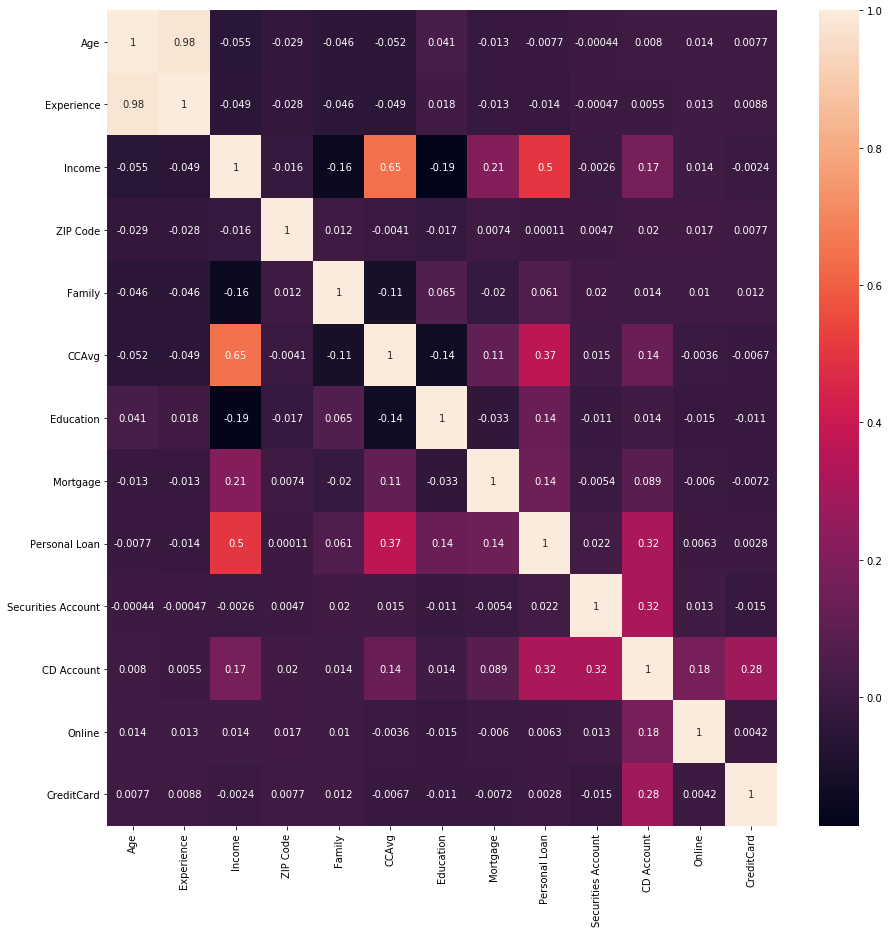

In [12]:
corr = thera_df.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True)


# 1. Age , Experience Income, Eduaction, Mortage - are intevral category variables
# 2. Personal Loan,  Securities Account, CD Account, Online, Credit card are bianry variables 
# 3. Income, CCAvg, Education, Mortgage & CD Account show lightly higher correlation with Personal Loan.

In [13]:
# peronal Loan Distribution 
thera_df['Personal Loan'].value_counts()

thera_df_loan= thera_df[thera_df['Personal Loan']==1]
thera_df_loan.describe().T

0    4520
1     480
Name: Personal Loan, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Age,480.0,45.066667,11.590964,26.0,35.00,45.0,55.0000,65.0
Experience,480.0,19.843750,11.582443,0.0,9.00,20.0,30.0000,41.0
Income,480.0,144.745833,31.584429,60.0,122.00,142.5,172.0000,203.0
ZIP Code,480.0,93153.202083,1759.223753,90016.0,91908.75,93407.0,94705.5000,96008.0
Family,480.0,2.612500,1.115393,1.0,2.00,3.0,4.0000,4.0
CCAvg,480.0,3.905354,2.097681,0.0,2.60,3.8,5.3475,10.0
Education,480.0,2.233333,0.753373,1.0,2.00,2.0,3.0000,3.0
Mortgage,480.0,100.845833,160.847862,0.0,0.00,0.0,192.5000,617.0
Personal Loan,480.0,1.000000,0.000000,1.0,1.00,1.0,1.0000,1.0
Securities Account,480.0,0.125000,0.331064,0.0,0.00,0.0,0.0000,1.0


In [14]:
# Splitting data into test and train

X = thera_df.drop("Personal Loan", axis=1)
y = thera_df["Personal Loan"]

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Logistic Regression

In [15]:
model_LR = LogisticRegression()

In [16]:
model_LR.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

In [17]:
def logisticRegModelPerformanceAnalysis(X, y, test_size = 0.3, seed = 7):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score]
    
    #### Optimize probability threshold and calculate performance numbers
    y_predictProb = model.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
    optimalF1 = 0
    optimalTh = 0
    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
        f1Score = f1_score(y_train, preds)
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th

    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score"])
    # Optimal probability threshold based train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Optimal probability threshold based test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
    
    cf = metrics.confusion_matrix(y_test,testPreds)
    
    return resultsDf, cf, sum(testPreds)

In [18]:
logisticRegModelPerformanceAnalysis(X, y, test_size = 0.3, seed = 7)[0]

C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.000000,1500.000000,3500.000000,1500.000000
optimalTh,0.500000,0.500000,0.170035,0.170035
accuracy,0.904857,0.918000,0.875143,0.886000
recall,0.307018,0.304348,0.722222,0.753623
precision,0.522388,0.608696,0.419355,0.431535
f1_score,0.386740,0.405797,0.530612,0.548813


In [19]:
cf_log=logisticRegModelPerformanceAnalysis(X, y, test_size = 0.3, seed = 7)[1]
sum_testpred_log=logisticRegModelPerformanceAnalysis(X, y, test_size = 0.3, seed = 7)[2]

C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


# K-NN 

In [20]:
NNH = KNeighborsClassifier(n_neighbors= 3)

In [21]:
NNH.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=3, p=2,
           weights='uniform')

In [22]:
cross_val=pd.DataFrame()

In [23]:
for i in range(1,30,2):
    NNH = KNeighborsClassifier(n_neighbors= i)
    NNH.fit(X_train, y_train)
    
    results1= pd.DataFrame(data=[i,NNH.score(X_train, y_train),1-NNH.score(X_train, y_train),
                                 NNH.score(X_test, y_test),1-NNH.score(X_test, y_test)],
                                 index=['neighbors','train_score','train_mse','test_score','test_mse']).T
    cross_val = cross_val.append(results1)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=1, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=3, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=7, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=9, p=2,
           weights='uniform')

...

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=21, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=23, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=25, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=27, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=29, p=2,
           weights='uniform')

In [24]:
cross_val=cross_val.sort_values(by="test_mse",ascending=True)
cross_val.head(1)

,neighbors,train_score,train_mse,test_score,test_mse
0,5.0,0.924857,0.075143,0.915333,0.084667


In [25]:
# Lowest MSE for neighbors 5 

In [26]:
NNH = KNeighborsClassifier(n_neighbors= 5)

In [27]:
NNH.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

In [28]:
testPreds = NNH.predict(X_test)

In [29]:
results1= pd.DataFrame(data=[5,NNH.score(X_train, y_train),1-NNH.score(X_train, y_train),
                             NNH.score(X_test, y_test),1-NNH.score(X_test, y_test)],
                       index=['neighbors','train_score','train_mse','test_score','test_mse']).T
results1

,neighbors,train_score,train_mse,test_score,test_mse
0,5.0,0.924857,0.075143,0.915333,0.084667


In [30]:
cf_Knn=metrics.confusion_matrix(y_test,testPreds)
cf_Knn

array([[1340,   22],
       [ 105,   33]], dtype=int64)

In [31]:
sum(testPreds)

55

# Naïve Bayes

In [32]:
GNB = GaussianNB()

In [33]:
#Fit the model
GNB.fit(X_train, y_train)
print(GNB)

GaussianNB(priors=None)

GaussianNB(priors=None)


In [34]:
preds = GNB.predict(X_test)

In [35]:
GNB.score(X_test, y_test)

0.88

In [36]:
results= pd.DataFrame(data=[accuracy_score(y_test, preds),recall_score(y_test, preds,average="macro"),
                            precision_score(y_test, preds, average="macro"),
                            f1_score(y_test, preds, average="macro")],
                      index=["accuracy", "recall", "precision", "f1_score"]).T

results

,accuracy,recall,precision,f1_score
0,0.88,0.75158,0.677391,0.704487


In [37]:
cf_gb=metrics.confusion_matrix(preds, y_test)

In [38]:
cf_gb

array([[1238,   56],
       [ 124,   82]], dtype=int64)

In [39]:
sum(preds)

206

# Logistic Classifier Confusion matrix

# Customers correctly tagged for loan -True Positive = 104
# Customers no contacted for loan, but took loan = 34

# Cost incurred because of wrong targetting - 137*cost

In [40]:
cf_log

array([[1225,  137],
       [  34,  104]], dtype=int64)

In [41]:
sum_testpred_log

241

In [42]:
104/138

0.7536231884057971

# KNN Confusion matrix

# Customers correctly tagged for loan -True Positive = 33
# Customers not contacted for loan, but took loan = 105

# Cost incurred because of wrong targetting - 22*cost

In [43]:
cf_Knn

array([[1340,   22],
       [ 105,   33]], dtype=int64)

In [44]:
# sum of test predicts =  55

In [45]:
33/138

0.2391304347826087

# Naive bayes Confusion matrix

# Customers correctly tagged for loan -True Positive = 82
# Customers not contacted for loan, but took loan = 56

# Cost incurred because of wrong targetting - 124*cost

In [46]:
cf_gb

array([[1238,   56],
       [ 124,   82]], dtype=int64)

In [47]:
# sum of test predicts 206

In [48]:
82/138

0.5942028985507246

# Conclusion
# Thera Bank wants to aggressively  increase asset base.
# As they are aggressive in marketing, Lets assume targetting cost is not a 
# deciding factor. 

# Instead lets go with the notion to have "Most number of Customer taking Personal loan"



# TPR Best for Logistic Regression with below optimalthershold

In [49]:
logisticRegModelPerformanceAnalysis(X, y, test_size = 0.3, seed = 7)[0]

C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Avinash Lappy\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.000000,1500.000000,3500.000000,1500.000000
optimalTh,0.500000,0.500000,0.170035,0.170035
accuracy,0.904857,0.918000,0.875143,0.886000
recall,0.307018,0.304348,0.722222,0.753623
precision,0.522388,0.608696,0.419355,0.431535
f1_score,0.386740,0.405797,0.530612,0.548813
